# 2a Escola de IA e Computação do CBPF (17-21/Ago/2026)

Curso de Astrofísica Computacional

Aula 2: Medidas de redshifts fotométricos de galáxias com aprendizado de máquina 

2.b) Medida de redshifts com florestas aleatórias

## Sumário

0. Introdução (descrição de ML, Decision Trees e Random Forest) (&#x2705; beta, v1)
1. Preparação de amostras de treino e teste (beta, v1)
2. ...

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error

from sklearn.ensemble import RandomForestRegressor

## Introdução

Os métodos de aprendizado de máquina que vamos empregar utilizam um subconjunto dos dados disponíveis para _treinar_ um algoritmo e outros subconjunto para _testar_ o resultado do treino e verificar a pe rformance do método em dados que não foram utilizados para o treinamento.

Esta linguagem é genérica e se aplica a todos os algoritmos, o que é prático para discutir os passos de uma dada análise. Por outro lado, ela obscurece o que está ocorrendo de fato no período de treinamento. Cada método possui seu próprio algoritmo, e estes possuem—na maior parte dos casos!—bases matemáticas robustas, calcadas na estatística e na teoria de otimização.

De forma muito resumida, **redes neurais** implementam numericamente um enorme "$f\odot g\odot h$" multidimensional, e o que chamamos de "treinamento" é o processo de tirar derivadas numéricas desta grande função multidimensional e não-linear buscando minimizar uma _função de perda_ (_loss function_), que no caso mais simples se trata de um $\chi^2$.

Já as **árvores de decisão** escolhem blablabalbalb.

**Florestas aleatórias** são um _ensemble method_ que treina múltiplas árvores de decisão, cada uma com blablablalal, e escolhe blablabla tal que blabalbala.

Neste notebook, vamos criar conjuntos de treino e teste (seção 1), aplicar cada um dos algoritmos acima aos nossos dados (seção 2) e avaliar sua performance (seção 3).

**FIXME:** Completar o texto desta célula.

## Exercício 1: Photo-zs com florestas aleatórias


### 1.a) Meça redshifts fotométricos usando as magnitudes disponíveis nos dados gerados na aula anterior

In [23]:
# Load the first CSV file (assumes it contains the test data)
data = pd.read_parquet("../../data/des_dr2/des_dr2_pz_training_set_clean_vvds_vipers_gama.pq")

# The 'z' columns is the target and the 'mag_*' and 'mag_err_' columns are the predictor
redshifts = data['z']
mags = data[['mag_auto_g_dered',
             'mag_auto_r_dered',
             'mag_auto_i_dered',
             'mag_auto_z_dered',
             'mag_auto_y_dered']]

In [24]:
# Split the data into training and test sets (e.g., 70/30 split)
Mags_train, Mags_test, z_spec_train, z_spec_test = train_test_split(mags, redshifts, test_size=0.3, random_state=42)

# Initialize the Random Forest Regressor with hyperparameters
# FIXME: Which hyperparameters should we use? (n_estimators, max_depth, etc.)
rf = RandomForestRegressor(n_estimators=50,
                           max_depth=30,
                           max_features=None)

# Train and evaluate the Random Forest model
rf.fit(Mags_train, z_spec_train)
z_phot_mags = rf.predict(Mags_test)
print(f"Random Forest Validation MAE: {mean_absolute_error(z_spec_test, z_phot_mags)}")

Random Forest Validation MAE: 0.05675013353972531


### 1.b) Calculate metrics (cf slides) and plot zphot vs zspec for the train and test samples

In [4]:
def calculate_metrics(z_spec, z_phot):
    # Calculate the metrics
    metrics = {}
    metrics['mae'] = mean_absolute_error(z_spec, z_phot)
    metrics['rmse'] = np.sqrt(mean_squared_error(z_spec, z_phot))

    metrics['std'] = np.std((z_phot - z_spec)/(1 + z_spec), ddof=1)
    metrics['nmad'] = 1.4826 * np.median(np.abs((z_phot - z_spec)/(1 + z_spec)))
    metrics['eta'] = np.sum(np.abs((z_phot - z_spec)/(1 + z_spec)) > 0.15) / len(z_spec) # Catastrophic outlier fraction
    metrics['bias'] = np.mean((z_phot - z_spec)/(1 + z_spec))
    metrics['sigbias'] = metrics['std']/np.sqrt(0.64 * len(z_spec)) # Standard error of the bias

    print('Standard Deviation: %6.4f' % metrics['std'])
    print('Normalized MAD: %6.4f' % metrics['nmad'])
    print('Catastrophic Outlier Fraction: %6.4f' % (100 * metrics['eta']))
    print('Median offset: %6.3f +/- %6.3f' % (metrics['bias'], metrics['sigbias']))

    return metrics


def plot_predictions(y_true, y_pred, title):
    x = np.linspace(min(y_true), max(y_true), 100)
    outlier_upper = x + 0.15 * (1 + x)
    outlier_lower = x - 0.15 * (1 + x)

    mask = np.abs((y_pred - y_true)/(1 + y_true)) > 0.15

    plt.figure(figsize=(4, 3))
    plt.scatter(y_true[mask], y_pred[mask], alpha=0.5, s=5, color='red', label='Outliers')
    plt.scatter(y_true[~mask], y_pred[~mask], alpha=0.5, s=5, color='blue', label='Non-Outliers')
    plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r')  # Diagonal line
    plt.plot(x, outlier_upper, 'k--')
    plt.plot(x, outlier_lower, 'k--')
    plt.xlabel('True Redshift')
    plt.ylabel('Predicted Redshift')
    plt.title(title)
    plt.legend()
    plt.grid()

    plt.xlim(0, 2)
    plt.ylim(0, 2)
    plt.show()

Standard Deviation: 0.0582
Normalized MAD: 0.0381
Catastrophic Outlier Fraction: 2.3143
Median offset:  0.003 +/-  0.000


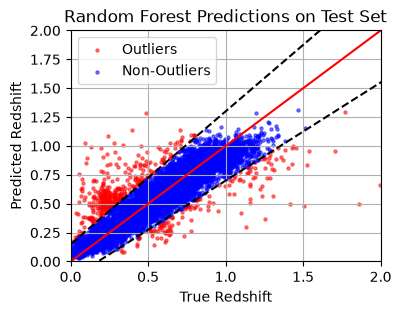

In [5]:
# Results on test set
_ = calculate_metrics(y_test, y_pred_rf)
_ = plot_predictions(y_test, y_pred_rf, "Random Forest Predictions on Test Set")

#### A side note: a practical example of overfitting

In [6]:
y_train_pred_rf, y_train = train_and_evaluate_rf(X_train, y_train, X_train, y_train)

Random Forest Validation MAE: 0.02145739907627374


Standard Deviation: 0.0582
Normalized MAD: 0.0381
Catastrophic Outlier Fraction: 2.3143
Median offset:  0.003 +/-  0.000


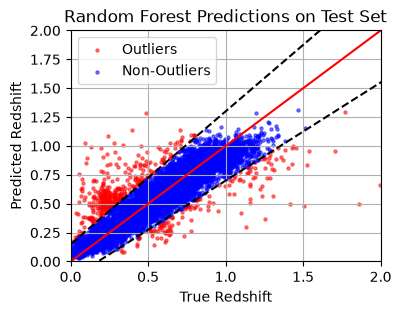

Standard Deviation: 0.0220
Normalized MAD: 0.0141
Catastrophic Outlier Fraction: 0.1341
Median offset:  0.001 +/-  0.000


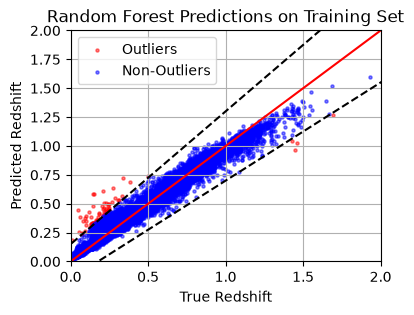

In [7]:
# Results on test set
_ = calculate_metrics(y_test, y_pred_rf)
_ = plot_predictions(y_test, y_pred_rf, "Random Forest Predictions on Test Set")

# Results on training set - WRONG, TOO OPTIMISTIC!
_ = calculate_metrics(y_train, y_train_pred_rf)
_ = plot_predictions(y_train, y_train_pred_rf, "Random Forest Predictions on Training Set")

### 1.c) Use k-fold cross-validation

In [8]:
n_folds = 5
del rf
rf = RandomForestRegressor(n_estimators=50,
                           max_depth=30,
                           max_features=None) # FIXME: Which hyperparameters should we use? (n_estimators, max_depth, etc.)


y_pred_cross_val = cross_val_predict(rf, mags, redshifts, cv=n_folds)

Standard Deviation: 0.0582
Normalized MAD: 0.0381
Catastrophic Outlier Fraction: 2.3143
Median offset:  0.003 +/-  0.000


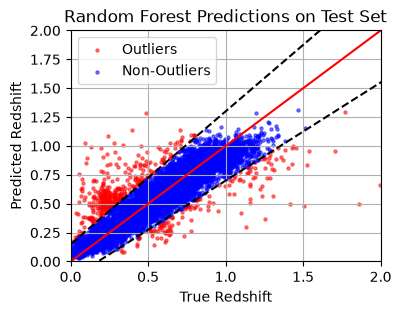

Standard Deviation: 0.0613
Normalized MAD: 0.0389
Catastrophic Outlier Fraction: 2.7547
Median offset:  0.004 +/-  0.000


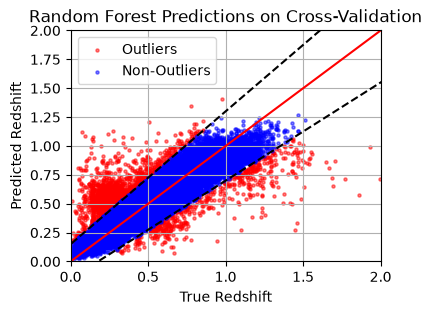

In [9]:
# Results on test set
_ = calculate_metrics(y_test, y_pred_rf)
_ = plot_predictions(y_test, y_pred_rf, "Random Forest Predictions on Test Set")

# Results on cross-validation - more realistic!
_ = calculate_metrics(redshifts, y_pred_cross_val)
_ = plot_predictions(redshifts, y_pred_cross_val, "Random Forest Predictions on Cross-Validation")

### 2.a) Crie subconjuntos dos dados com as colunas necessárias para cada um dos testes planejados

In [31]:
print(data.columns.values)

<ArrowStringArray>
[ 'coadd_object_id',               'ra',              'dec',
                'z',            'err_z',         'flag_des',
           'survey',      'flag_survey', 'mag_auto_g_dered',
 'mag_auto_r_dered', 'mag_auto_i_dered', 'mag_auto_z_dered',
 'mag_auto_y_dered',    'magerr_auto_g',    'magerr_auto_r',
    'magerr_auto_i',    'magerr_auto_z',    'magerr_auto_y',
           'ra_mpl',          'dec_mpl',        'g_minus_r',
        'r_minus_i',        'i_minus_z',        'z_minus_y']
Length: 24, dtype: str


In [36]:
# Load the first CSV file (assumes it contains the test data)
data = pd.read_parquet("../../data/des_dr2/des_dr2_pz_training_set_clean_vvds_vipers_gama.pq")

# The 'z' columns is the target and the 'mag_*' and 'mag_err_' columns are the predictor
redshifts = data['z']
mags = data[['mag_auto_g_dered',
             'mag_auto_r_dered',
             'mag_auto_i_dered',
             'mag_auto_z_dered',
             'mag_auto_y_dered']]

colors = data[['g_minus_r',
               'r_minus_i',
               'i_minus_z',
               'z_minus_y']]

clrmag = data[['g_minus_r',
               'r_minus_i',
               'i_minus_z',
               'z_minus_y',
               'mag_auto_i_dered']]

mags_werr = data[['mag_auto_g_dered',
                  'mag_auto_r_dered',
                  'mag_auto_i_dered',
                  'mag_auto_z_dered',
                  'mag_auto_y_dered',
                  'magerr_auto_g',
                  'magerr_auto_r',
                  'magerr_auto_i',
                  'magerr_auto_z',
                  'magerr_auto_y']]

clrmag_werr = data[['g_minus_r',
                    'r_minus_i',
                    'i_minus_z',
                    'z_minus_y',
                    'mag_auto_i_dered',
                    'magerr_auto_g',
                    'magerr_auto_r',
                    'magerr_auto_i',
                    'magerr_auto_z',
                    'magerr_auto_y']]

#### Colors

In [11]:
# Split the data into training and test sets (e.g., 70/30 split)
del rf
rf = RandomForestRegressor(n_estimators=50,
                           max_depth=30,
                           max_features=None) # FIXME: Which hyperparameters should we use? (n_estimators, max_depth, etc.)

X_train_color, X_test_color, y_train_color, y_test_color = train_test_split(colors, redshifts, test_size=0.3, random_state=42)
y_pred_colors, y_test_colors = train_and_evaluate_rf(X_train_color, y_train_color, X_test_color, y_test_color)

Random Forest Validation MAE: 0.0660016461589757


#### Colors + Magnitudes

In [33]:
from sklearn.base import clone
rf = clone(rf)   

X_train_clrmag, X_test_clrmag, y_train_clrmag, y_test_clrmag = train_test_split(clrmag, redshifts, test_size=0.3, random_state=42)
y_pred_clrmag, y_test_clrmag = train_and_evaluate_rf(X_train_clrmag, y_train_clrmag, X_test_clrmag, y_test_clrmag)

Random Forest Validation MAE: 0.05305893679926191


In [34]:
rf = clone(rf)   
X_train_mag_werr, X_test_mag_werr, y_train_mag_werr, y_test_mag_werr = train_test_split(mags_werr, redshifts, test_size=0.3, random_state=42)
y_pred_mag_werr, y_test_mag_werr = train_and_evaluate_rf(X_train_mag_werr, y_train_mag_werr, X_test_mag_werr, y_test_mag_werr)

Random Forest Validation MAE: 0.06173370674713484


In [37]:
rf = clone(rf)   
X_train_clrmag_werr, X_test_clrmag_werr, y_train_clrmag_werr, y_test_clrmag_werr = train_test_split(clrmag_werr, redshifts, test_size=0.3, random_state=42)
y_pred_clrmag_werr, y_test_clrmag_werr = train_and_evaluate_rf(X_train_clrmag_werr, y_train_clrmag_werr, X_test_clrmag_werr, y_test_clrmag_werr)

Random Forest Validation MAE: 0.0519715670868637


#### Plots

Standard Deviation: 0.0582
Normalized MAD: 0.0381
Catastrophic Outlier Fraction: 2.3143
Median offset:  0.003 +/-  0.000


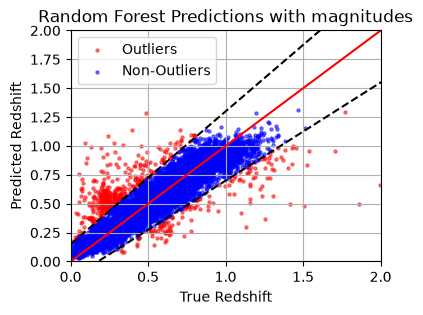

Standard Deviation: 0.0697
Normalized MAD: 0.0406
Catastrophic Outlier Fraction: 4.7520
Median offset:  0.004 +/-  0.001


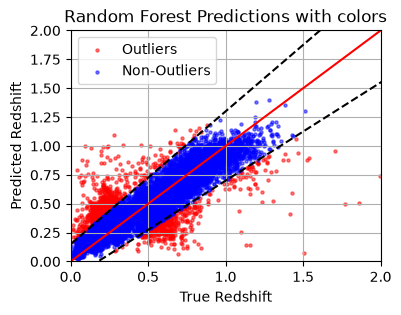

Standard Deviation: 0.0564
Normalized MAD: 0.0339
Catastrophic Outlier Fraction: 2.1556
Median offset:  0.003 +/-  0.000


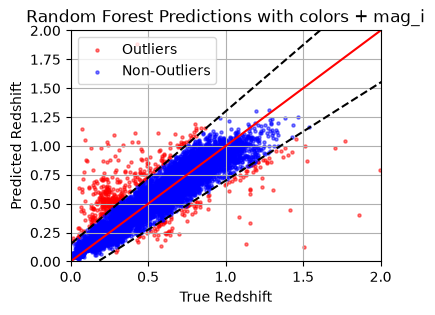

Standard Deviation: 0.0618
Normalized MAD: 0.0431
Catastrophic Outlier Fraction: 2.4774
Median offset:  0.003 +/-  0.001


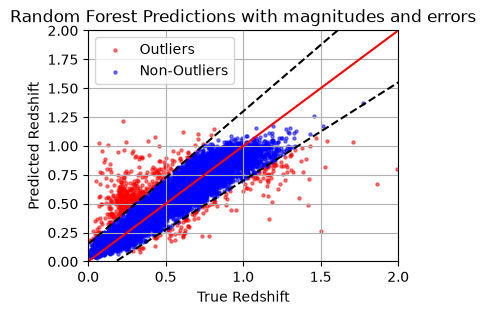

Standard Deviation: 0.0547
Normalized MAD: 0.0329
Catastrophic Outlier Fraction: 2.0145
Median offset:  0.002 +/-  0.000


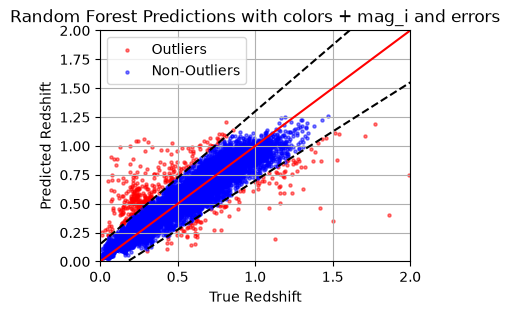

In [38]:
# Results on test set
_ = calculate_metrics(y_test, y_pred_rf)
_ = plot_predictions(y_test, y_pred_rf, "Random Forest Predictions with magnitudes")

# Results on colors test set
_ = calculate_metrics(y_test_colors, y_pred_colors)
_ = plot_predictions(y_test_colors, y_pred_colors, "Random Forest Predictions with colors")

# Results on colors + mag_i test set
_ = calculate_metrics(y_test_clrmag, y_pred_clrmag)
_ = plot_predictions(y_test_clrmag, y_pred_clrmag, "Random Forest Predictions with colors + mag_i")

# Results on magnitudes with errors test set
_ = calculate_metrics(y_test_mag_werr, y_pred_mag_werr)
_ = plot_predictions(y_test_mag_werr, y_pred_mag_werr, "Random Forest Predictions with magnitudes and errors")


# Results on colors + mag_i with errors test set
_ = calculate_metrics(y_test_clrmag_werr, y_pred_clrmag_werr)
_ = plot_predictions(y_test_clrmag_werr, y_pred_clrmag_werr, "Random Forest Predictions with colors + mag_i and errors")

## Exercício 2:  Métricas de qualidade e otimização de hiperparâmetros

## Exercício 3: Testando variantes na escolha das análises

In [14]:
def plot_metrics(zspec,
                 zphot,
                 maximum,
                 path_to_save='',
                 title=None,
                 initial=0):
    
    '''
    Function to plot Bias, Sigma_68, Out2σ, Out3σ given a spectroscopic and photometric redshift. 
    
    Args:
    
    zspec: Numpy array with the spectroscopic redshift.
    
    zphot: Numpy array with the photometric redshifts calculated. Same size as zspec.
    
    maximum: Float that indicates the redshift max of the plots.
    
    Kwargs:
    
    initial: Float that indicates the redshift min of the plots.
    
    
    
    '''
    bins = np.arange(0, 1.3, 0.1)
    points = bins + 0.05
    fraction_outliers = []
    sigma68z = []
    sigmaz = []
    meanz = []
    outliers_2 = []
    drop_bins = []

    for index in range(len(bins) - 1):
        bin_lower = bins[index]
        bin_upper = bins[index + 1]

        binmask = (zphot >= bin_lower) & (zphot <= bin_upper)

        if not np.any(binmask):
            drop_bins.append(index)
            continue
        
        values_r = zphot[binmask]
        values_s = zspec[binmask]

        deltabias = (values_r - values_s)
        mean_bias = np.mean(deltabias)  # Mean bias for each bin
        meanz.append(mean_bias)
        
        # FIXME: This part of the code is really bad. That's not how you calculate a quantile!
        s = np.sort(np.abs(deltabias/(1 + values_s))) # Standard deviation (sigma) for each bin
        sigma68 = s[int(len(s)*0.68)]
        sigma68z.append(sigma68)
        
        # FIXME: This part of the code is really bad. That's not how you calculate a standard deviation!
        sigma = (np.sum((values_r-values_s-mean_bias)**2)/len(values_r))**0.5
        sigmaz.append(sigma)
    
        # Calculate the fraction of outliers outside 3 sigma
        outliers = deltabias[np.abs(deltabias - mean_bias) > 3 * sigma]
        fraction_outlier = len(outliers) / len(deltabias)
        fraction_outliers.append(fraction_outlier)
    
        #2 sigma
        outliers2 = deltabias[np.abs(deltabias-mean_bias) > 2 * sigma]
        fraction_outlier2 = len(outliers2) / len(deltabias)
        outliers_2.append(fraction_outlier2)

    points = np.delete(points, drop_bins)


    fig, axes = plt.subplots(4, 1, figsize=(8, 4), sharex=True)
    plt.subplots_adjust(hspace=0.1) 

    axes[1]
    x_lim = (0, np.max(bins))

    # Subplot 1: Mean Bias
    axes[0].plot(points[:-1], meanz, 'bo-')
    axes[0].axhline(0, color='black', linestyle='--')
    axes[0].set_ylabel(r'$\Delta z$', fontsize=20)
    axes[0].set_xlim(x_lim)
    #axes[0].set_ylim(-0.05, 0.05)
    axes[0].tick_params(axis='both', labelsize=14)
    axes[0].grid(True)

    # Subplot 2: Sigma 68
    axes[1].plot(points[:-1], sigma68z, 'go-')
    axes[1].set_ylabel(r'$\sigma_{68}$', fontsize=20)
    axes[1].set_xlim(x_lim)
    axes[1].axhline(0.12, color='black', linestyle='--')
    #axes[1].set_ylim(0,max(sigmaz)+0.01)
    #axes[1].set_ylim(0, 0.03)
    axes[1].set_xlim(x_lim)
    axes[1].axhline(0.12, color='black', linestyle='--')
    #axes[1].set_ylim(0,max(sigmaz)+0.01)
    #axes[1].set_ylim(0, 0.03)
    axes[1].set_yticks(np.arange(0, 0.25, 0.05))
    axes[1].tick_params(axis='both', labelsize=14)
    axes[1].grid(True)


    # Subplot3: 2_outliers
    axes[2].plot(points[:-1],outliers_2,'o-',color='darkorange')
    #axes[2].set_xlabel(r'$Z_{phot}$', fontsize=20)
    axes[2].set_ylabel('out$_{2σ}$', fontsize=20)
    axes[2].set_xlim(x_lim)
    #axes[2].set_ylim(0,0.12)
    axes[2].axhline(0.1, color='black', linestyle='--')
    axes[2].tick_params(axis='both', labelsize=14)
    axes[2].grid(True)
    #axes[2].yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

    # Subplot 4: 3_outliers
    axes[3].plot(points[:-1], fraction_outliers, 'ro-')
    axes[3].set_xlabel(r'$Z_{spec}$', fontsize=20)
    axes[3].set_ylabel('out$_{3σ}$', fontsize=20)
    axes[3].set_xlim(x_lim)
    #axes[3].set_ylim(0,0.12)
    axes[3].axhline(0.1, color='black', linestyle='--')
    axes[3].tick_params(axis='both', labelsize=14)
    axes[3].grid(True)
   

    plt.suptitle(title)
    plt.xlim(0, 1.3)
    plt.tight_layout()

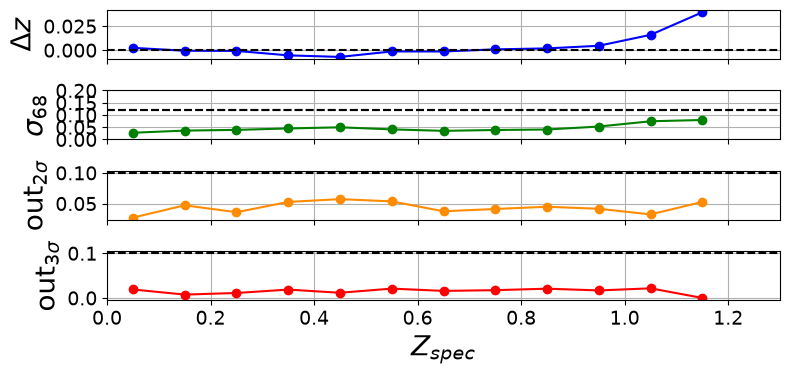

In [15]:
plot_metrics(y_test, y_pred_rf, 1.6, initial=0)

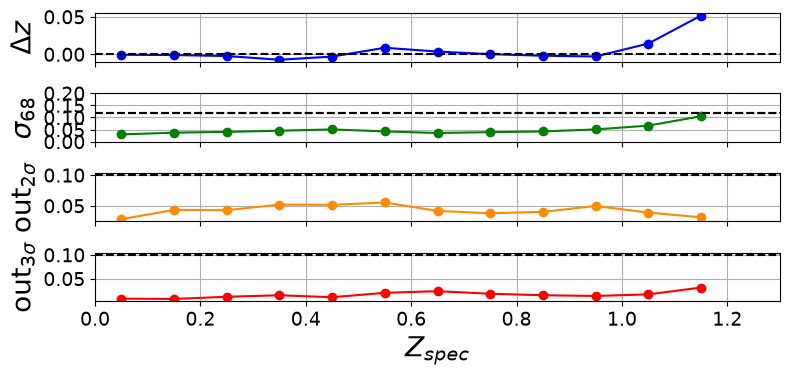

In [16]:
plot_metrics(redshifts, y_pred_cross_val, 1.6, initial=0)

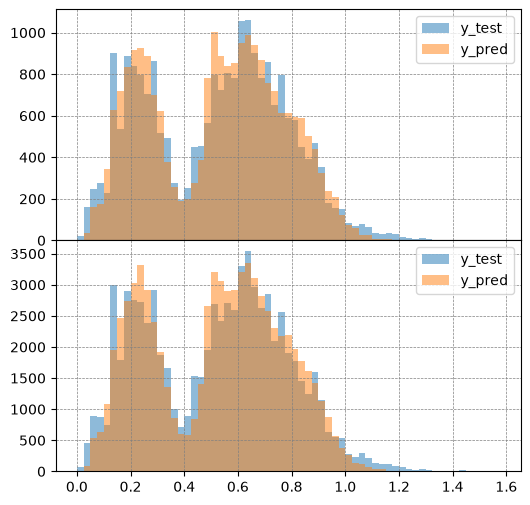

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(6, 6), sharex=False)
plt.subplots_adjust(hspace=0.)

ax = axes[0]
#ax.set_xlabel('z', fontsize = 17)
ax.grid(color = 'gray', linestyle = '--', linewidth = 0.5) 
_ = ax.hist(y_test, bins=np.arange(0, 1.6, 0.025), density=False, color='C0', alpha=0.5)
_ = ax.hist(y_pred_rf, bins=np.arange(0, 1.6, 0.025), density=False, color='C1', alpha=0.5)
#ax.set_ylim(0, 160)
ax.legend(['y_test', 'y_pred'])

ax = axes[1]

#ax.set_xlabel('z', fontsize = 17)
ax.grid(color = 'gray', linestyle = '--', linewidth = 0.5) 
_ = ax.hist(redshifts, bins=np.arange(0, 1.6, 0.025), density=False, color='C0', alpha=0.5)
_ = ax.hist(y_pred_cross_val, bins=np.arange(0, 1.6, 0.025), density=False, color='C1', alpha=0.5)
#ax.set_ylim(0, 160)
ax.legend(['y_test', 'y_pred'])

# SOBRAS

## 2. Treino/teste de três algoritmos de aprendizado de máquina

### 2.1. Rede neural (Multi-layer perceptron)

In [18]:
from sklearn.neural_network import MLPRegressor

mlp = MLPRegressor(random_state=42)
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)

mlp_test_mae = mean_absolute_error(y_test, y_pred_mlp)
print("Multi-Layer Perceptron Validation MAE:", mlp_test_mae)

Multi-Layer Perceptron Validation MAE: 0.0759030763635313


### 2.2. Árvore de decisão

In [19]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

dt_test_mae = mean_absolute_error(y_test, y_pred_dt)
print("Decision Tree Validation MAE:", dt_test_mae)

Decision Tree Validation MAE: 0.07878402305884946


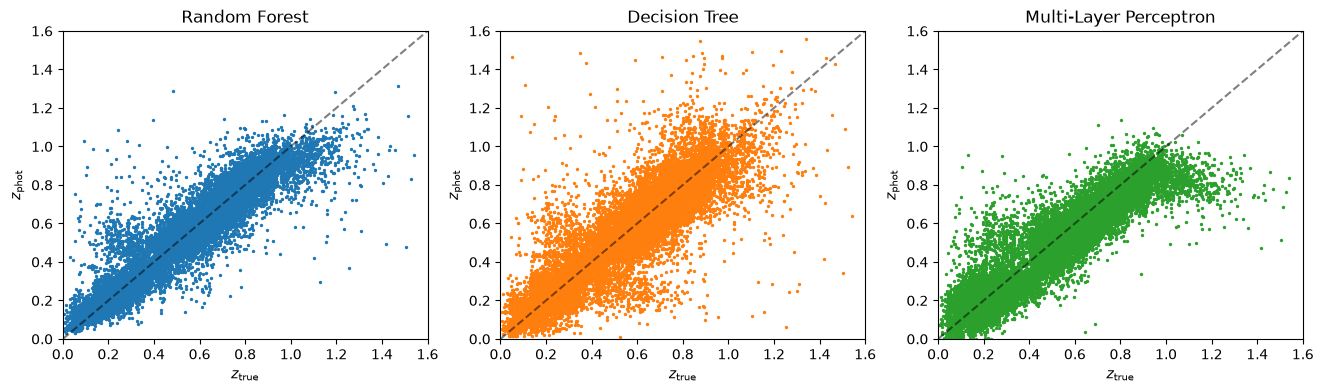

In [20]:
# Compare plots from three results

titles = ["Multi-Layer perceptron", "Decision tree", "Random forest"]
data_sets = [y_pred_mlp, y_pred_dt, y_pred_rf]
colors = ["C0", "C1", "C2"]

plt.figure(figsize=(16, 4))

plt.subplot(1, 3, 1)
plt.title("Random Forest")
plt.scatter(y_test, y_pred_rf, s=2, color="C0")
x = np.linspace(0, 1.6, 100)
plt.plot(x, x, "k--", alpha=0.5)
plt.ylim(0, 1.6)
plt.xlim(0, 1.6)
plt.xlabel(r"$z_\mathrm{true}$")
plt.ylabel(r"$z_\mathrm{phot}$")

plt.subplot(1, 3, 2)
plt.title("Decision Tree")
plt.scatter(y_test, y_pred_dt, s=2, color="C1")
x = np.linspace(0, 1.6, 100)
plt.plot(x, x, "k--", alpha=0.5)
plt.ylim(0, 1.6)
plt.xlim(0, 1.6)
plt.xlabel(r"$z_\mathrm{true}$")
plt.ylabel(r"$z_\mathrm{phot}$")

plt.subplot(1, 3, 3)
plt.title("Multi-Layer Perceptron")
plt.scatter(y_test, y_pred_mlp, s=2, color="C2")
x = np.linspace(0, 1.6, 100)
plt.plot(x, x, "k--", alpha=0.5)
plt.ylim(0, 1.6)
plt.xlim(0, 1.6)
_ = plt.xlabel(r"$z_\mathrm{true}$")
_ = plt.ylabel(r"$z_\mathrm{phot}$")